# **Section A: Machine Vision System Implementation (OpenCV)**

## A.1. Simulation and Generation of the Workspace Image

Although in production the image arrives from a real camera, for a fully reproducible assignment we synthesise it. Treat the function below as the "camera driver". **Do not modify** this cell — it is the source of truth that your pipeline will be evaluated against.

The image contains:
- Four black corner markers (the calibration fiducials).
- 5 colored discs whose **ground-truth world coordinates** are stored in `GROUND_TRUTH_DISCS`.
- A simulated tilted view (homography), camera vignetting and Gaussian noise.

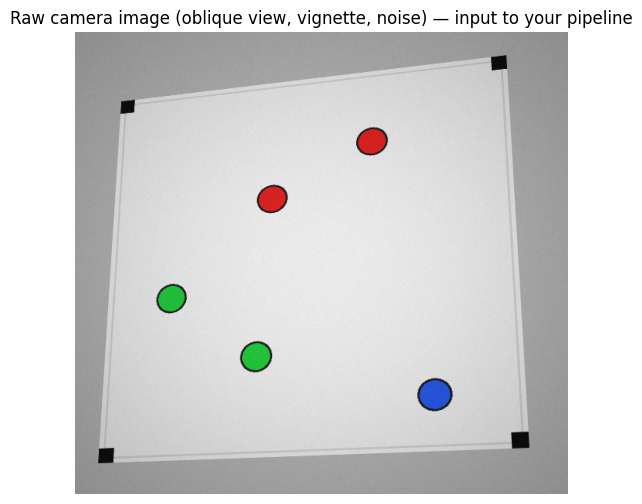

Image shape: (600, 640, 3)


In [2]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt


# ============================================================
#   A.1  —  Synthetic workbench image generator (camera driver)
# ============================================================
# Bench dimensions in metres (the robot's working area)
BENCH_HALF = 0.30                 # ± 0.30 m on both axes
WORLD_CORNERS_M = np.array([      # in robot-base frame  (x, y)
    [+0.30, +0.30],   # TL
    [+0.30, -0.30],   # TR
    [-0.30, -0.30],   # BR
    [-0.30, +0.30],   # BL
], dtype=np.float32)

# Ground-truth coloured discs (NOT visible to the student pipeline)
GROUND_TRUTH_DISCS = [
    {"color": "red",   "world_xy": (+0.18, -0.10)},
    {"color": "green", "world_xy": (-0.05, +0.20)},
    {"color": "blue",  "world_xy": (-0.22, -0.18)},
    {"color": "red",   "world_xy": (+0.10, +0.05)},
    {"color": "green", "world_xy": (-0.15, +0.07)},
]

DISC_RGB = {"red":   (220,  35,  35),
            "green": ( 35, 200,  60),
            "blue":  ( 40,  90, 230)}


def _render_topdown_truth(canvas_size=600):
    """Render an ideal (un-distorted) top-down RGB view of the bench."""
    img = np.full((canvas_size, canvas_size, 3), 235, dtype=np.uint8)  # light-gray bench

    # Helper: world (m) -> pixel (px) in this canonical canvas
    def w2p(xy):
        # World x grows UP on the bench, world y grows LEFT (right-handed,
        # z up). In the top-down image:  u = (canvas/2) - y/half * canvas/2
        #                                v = (canvas/2) - x/half * canvas/2
        u = int((canvas_size/2) - (xy[1] / BENCH_HALF) * (canvas_size/2))
        v = int((canvas_size/2) - (xy[0] / BENCH_HALF) * (canvas_size/2))
        return (u, v)

    # Bench border (subtle)
    cv2.rectangle(img, (8, 8), (canvas_size-8, canvas_size-8), (210, 210, 210), 2)

    # 1.  Black corner markers — 40-px squares
    msz = 22
    for w_xy in WORLD_CORNERS_M:
        u, v = w2p(w_xy)
        cv2.rectangle(img, (u-msz, v-msz), (u+msz, v+msz), (15, 15, 15), -1)

    # 2.  Coloured discs
    for d in GROUND_TRUTH_DISCS:
        u, v = w2p(d["world_xy"])
        bgr = DISC_RGB[d["color"]][::-1]
        cv2.circle(img, (u, v), 22, bgr, -1)
        cv2.circle(img, (u, v), 22, (30, 30, 30), 2)   # outline

    return img


def capture_workbench_image(seed=7):
    """Return the *raw* camera image: tilted view, vignetting, Gaussian noise."""
    rng = np.random.default_rng(seed)

    truth = _render_topdown_truth(600)

    # Apply a fixed projective distortion (camera looking from upper-right)
    src = np.float32([[0, 0], [600, 0], [600, 600], [0, 600]])
    dst = np.float32([[ 60,  90],
                      [560,  30],
                      [590, 540],
                      [ 30, 560]])
    H = cv2.getPerspectiveTransform(src, dst)
    warped = cv2.warpPerspective(truth, H, (640, 600),
                                 borderValue=(180, 180, 180))

    # Vignette
    rows, cols = warped.shape[:2]
    kx = cv2.getGaussianKernel(cols, cols/1.6)
    ky = cv2.getGaussianKernel(rows, rows/1.6)
    mask = (ky @ kx.T)
    mask = mask / mask.max()
    warped = (warped.astype(np.float32) * (0.55 + 0.45*mask[..., None])).clip(0, 255)

    # Mild Gaussian noise
    noise = rng.normal(0, 4.0, warped.shape)
    warped = (warped + noise).clip(0, 255).astype(np.uint8)
    return warped


# Capture and display
raw = capture_workbench_image()
plt.figure(figsize=(7, 6))
plt.imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB))
plt.title("Raw camera image (oblique view, vignette, noise) — input to your pipeline")
plt.axis('off')
plt.show()
print(f"Image shape: {raw.shape}")


## A.2. Detection of the Four Table Corner Markers

The objective of this stage is to automatically locate the four black square markers positioned at the corners of the workbench. 

The output must be a sorted array of coordinates representing these points in a strict **clockwise sequence**, starting from the top-left corner:
1. **TL** (Top-Left)
2. **TR** (Top-Right)
3. **BR** (Bottom-Right)
4. **BL** (Bottom-Left)

*Note: Enforcing this specific order is essential for mapping the pixel coordinates to the robot's real-world workspace coordinates (`WORLD_CORNERS_M`) in subsequent steps.*

---

***Algorithmic Workflow***

The detection pipeline utilizes standard computer vision techniques implemented in OpenCV:

1. **Color Space Conversion & Thresholding:** The image is converted from RGB to the **HSV** color space. The **Value (V) channel** is extracted since it isolates brightness. An inverse binary threshold (`cv2.THRESH_BINARY_INV`) is applied to turn the dark square regions into white objects on a black background.
2. **Noise Reduction:** A morphological opening operation is executed using a small $3 \times 3$ kernel to clean up minor artifacts and salt-and-pepper noise.
3. **Contour Extraction:** External contours are extracted from the cleaned binary mask.
4. **Geometric Filtering:** To isolate the markers from other dark objects or noise, contours are filtered using two strict criteria:
    *   **Area Thresholding:** Eliminates small contours ($Area \le 100$).
    *   **Squareness (Extent):** Evaluates the ratio of the contour area to the area of its bounding box ($Extent = \frac{\text{Contour Area}}{\text{Bounding Box Area}}$). For a true square, this value approaches $1.0$. A tolerance threshold ($> 0.7$) ensures only square-like shapes are kept.
5. **Centroid Calculation:** The precise pixel coordinates $(c_x, c_y)$ of the valid markers are computed using spatial image moments.
6. **Clockwise Sorting:** The extracted points are organized using geometric heuristics:
    *   **TL / BR:** The sum of coordinates $(x + y)$ is minimized at the Top-Left and maximized at the Bottom-Right.
    *   **TR / BL:** The difference between coordinates $(y - x)$ is minimized at the Top-Right and maximized at the Bottom-Left.

In [3]:
def detect_and_sort_corners(image):
    """
    Detects the four black corner markers and sorts them in the order:
    Top-Left (TL), Top-Right (TR), Bottom-Right (BR), Bottom-Left (BL).
    """
    # 1. Convert to HSV and extract the Value (V) channel
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    v_channel = hsv[:, :, 2]
    
    # 2. Thresholding: Dark regions become white (255), others black (0)
    # A threshold value of 60 is used (can be tuned depending on illumination)
    _, thresh = cv2.threshold(v_channel, 60, 255, cv2.THRESH_BINARY_INV)
    
    # Optional: Perform morphological opening to remove small noise
    kernel = np.ones((3,3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
    
    # 3. Detect contours from the binary image
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    marker_centers = []
    
    # 4. Filter contours based on area and squareness (Extent)
    for cnt in contours:
        area = cv2.contourArea(cnt)
        
        # Skip small contours (noise)
        if area > 100:
            x, y, w, h = cv2.boundingRect(cnt)
            rect_area = w * h
            extent = area / rect_area
            
            # For a square, extent ≈ 1.0; allow tolerance (e.g., > 0.7)
            if extent > 0.7:
                # Calculate centroid using image moments
                M = cv2.moments(cnt)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                    marker_centers.append([cx, cy])
                    
    # Ensure exactly four markers are detected
    if len(marker_centers) != 4:
        raise ValueError(f"Expected 4 markers, but found {len(marker_centers)}.")
        
    # 5. Sort coordinates: TL, TR, BR, BL
    pts = np.array(marker_centers, dtype="float32")
    sorted_pts = np.zeros((4, 2), dtype="float32")
    
    # Sum of x+y → TL has the smallest sum, BR has the largest
    s = pts.sum(axis=1)
    sorted_pts[0] = pts[np.argmin(s)]  # Top-Left
    sorted_pts[2] = pts[np.argmax(s)]  # Bottom-Right
    
    # Difference (y-x) → TR has smallest diff, BL has largest
    diff = np.diff(pts, axis=1)
    sorted_pts[1] = pts[np.argmin(diff)]  # Top-Right
    sorted_pts[3] = pts[np.argmax(diff)]  # Bottom-Left
    
    return sorted_pts

image_corners = detect_and_sort_corners(raw)
print("Detected Corner Points (TL, TR, BR, BL):\n", image_corners)


Detected Corner Points (TL, TR, BR, BL):
 [[ 67.  96.]
 [550.  39.]
 [577. 529.]
 [ 39. 549.]]



### Create a copy of the image for visualization (to preserve the original)

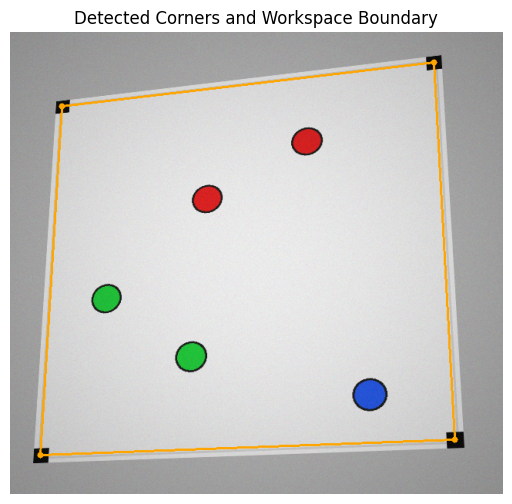

In [4]:

# Create a copy of the image for visualization (to preserve the original)
vis_image = raw.copy()

# Define the orange color in BGR format (Blue=0, Green=165, Red=255)
orange_color = (0, 165, 255)

# Convert the coordinates to proper integer array format for drawing
pts = image_corners.astype(np.int32)
pts = pts.reshape((-1, 1, 2))

# Draw a closed polygon connecting the four corner points
cv2.polylines(vis_image, [pts], isClosed=True, color=orange_color, thickness=2)

# Draw small filled circles on each detected corner point
for pt in image_corners:
    x, y = int(pt[0]), int(pt[1])
    cv2.circle(vis_image, (x, y), radius=4, color=orange_color, thickness=-1)

# Display the output image
plt.figure(figsize=(8, 6))
# Convert BGR to RGB for proper color display in matplotlib
plt.imshow(cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB))
plt.title("Detected Corners and Workspace Boundary")
plt.axis('off')
plt.show()


## A.3. Perspective Correction (Top-Down View Transformation)


After successfully locating the four pixel corner coordinates from the raw oblique frame, the next step maps them to an ideal, normalized top-down plane. This process corrects the spatial distortion caused by the camera's tilt and viewing angle, generating a metric representation of the workspace.

### Geometric Specifications & Scale Factor
To transition from pixel space to real-world physical units, the rectified canvas adheres to a strict scaling metric:
*   **Scale Factor:** $1 \text{ meter} = 1000 \text{ pixels}$ (or $1 \text{ mm} = 1 \text{ pixel}$).
*   **Dimensions:** Since the actual physical workbench spans a $60 \times 60 \text{ cm}$ area ($0.6 \times 0.6 \text{ m}$), the resulting rectified output image is precisely $600 \times 600 \text{ pixels}$.
*   **Workspace Centering:** Under this canonical framing, the physical center point of the workbench maps exactly to the pixel coordinates $(300, 300)$.

---

### Technical Workflow

The algorithm computes a projective mapping using spatial matrices:

1. **Destination Point Mapping:** An destination coordinate array (`dst_pts`) is configured to match the $600 \times 600 \text{ px}$ image grid bounding limits, mirroring the standard clockwise alignment sequence (**TL, TR, BR, BL**) verified in Task A.2.
2. **Homography Matrix Estimation:** The perspective transformation model utilizes OpenCV's `cv2.getPerspectiveTransform()`. It resolves the linear equations matching the distorted input coordinates (`src_pts`) to the true metric layout (`dst_pts`), returning a $3 \times 3$ Homography matrix ($H$).
3. **Image Warping:** The raw distorted sensor array is resampled using `cv2.warpPerspective()`, computing the inverse projective transform to form a clean overhead orthogonal view.
4. **Metric Verification Grid:** To visually validate the geometric scaling accuracy, a verification overlay grid is drawn on top of the output. 
    *   **Spacing Rule:** A 6 cm physical spacing step translates directly to a constant $\Delta = 60 \text{ pixels}$ interval.
    *   A loop sweeps across the axes, drawing horizontal and vertical reference lines to ensure the workbench coordinates preserve correct aspect ratios.

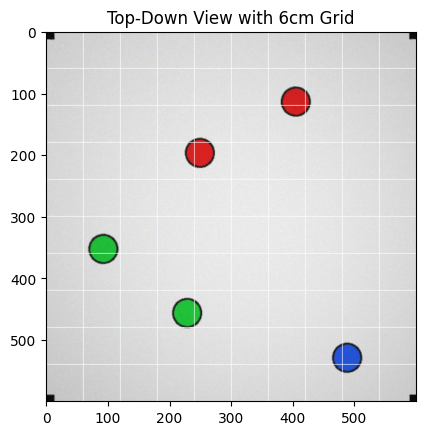

In [5]:


def perspective_correction_and_grid(raw_image, src_pts):
    # 1. Define scale and dimensions
    PIXELS_PER_METER = 1000
    WORKBENCH_SIZE_M = 0.6
    
    # Final image size in pixels (600x600)
    img_size = int(WORKBENCH_SIZE_M * PIXELS_PER_METER) 
    
    # 2. Define destination pixel coordinates (Order: TL, TR, BR, BL)
    dst_pts = np.array([
        [0, 0],                   # Top-Left
        [img_size, 0],            # Top-Right
        [img_size, img_size],     # Bottom-Right
        [0, img_size]             # Bottom-Left
    ], dtype=np.float32)
    
    # Ensure input points are float32 data type
    src_pts = np.array(src_pts, dtype=np.float32)
    
    # 3. Calculate the Homography matrix
    H = cv2.getPerspectiveTransform(src_pts, dst_pts)
    
    # 4. Apply perspective transformation (Warping)
    warped_image = cv2.warpPerspective(raw_image, H, (img_size, img_size))
    
    # 5. Draw grid with 6 cm spacing (60 pixels)
    grid_image = warped_image.copy()
    step_cm = 6
    step_px = int((step_cm / 100.0) * PIXELS_PER_METER) # 60 pixels
    
    # Draw vertical and horizontal lines with white color and thickness 1
    for x in range(0, img_size + 1, step_px):
        cv2.line(grid_image, (x, 0), (x, img_size), (255, 255, 255), 1)
    for y in range(0, img_size + 1, step_px):
        cv2.line(grid_image, (0, y), (img_size, y), (255, 255, 255), 1)
        
    return warped_image, grid_image, H

# ---------------------------------------------------------
# Assuming `src_pts` is the output from the previous task and `raw_image` is the original image
src_pts = np.array([[ 67, 96], [550, 39], [577, 529], [ 39, 549]])
warped_img, grid_img, H_matrix = perspective_correction_and_grid(raw, src_pts)

# For display:
plt.imshow(cv2.cvtColor(grid_img, cv2.COLOR_BGR2RGB))
plt.title("Top-Down View with 6cm Grid")
plt.show()



## A.4. Segmentation and Disc Detection in HSV Space


This phase extracts the target objects (red, green, and blue colored discs) from the rectified top-down workspace image and calculates the precise pixel coordinates of their centroids.

### Technical Challenges & Solutions

Developing a robust segmentation pipeline requires addressing several physical and environmental constraints:

*   **Red Hue Wrap-Around:** In the HSV color cylinder, the Hue (H) channel ranges from $0^{\circ}$ to $360^{\circ}$ (mapped to $0-179$ in OpenCV). The red spectrum resides at both edges of this boundary (near $0$ and near $180$). To avoid missing data, the algorithm implements a dual-mask approach, combining both ranges via a bitwise OR operation.
*   **Residual Vignetting and Illumination Shifts:** Despite perspective correction, subtle lighting gradients and lens shadows persist near the workspace margins. The algorithm counteracts this by utilizing dynamic saturation (S) and value (V) tolerances to keep color masking reliable under variable brightness.
*   **Adjacent/Touching Objects:** Discs of identical color placed in close proximity can merge into a single contiguous shape in a basic binary mask. To accurately separate individual items:
    1.  An **elliptical morphological opening** operation (`cv2.MORPH_OPEN`) cleans up localized background noise and detaches weak, superficial boundaries between adjacent discs.
    2.  **Connected Component Analysis (CCA)** with 8-way connectivity (`cv2.connectedComponentsWithStats`) parses individual labels, ensuring overlapping or touching blobs are isolated and calculated as separate entities.

---

### Algorithmic Workflow

1.  **Color Space Re-mapping:** Converts the rectified BGR image into the HSV color space.
2.  **Color Threshold Masking:** Apples color ranges using `cv2.inRange()`. The specialized boundaries are set as follows:
    *   **Red:** Combines $0 \le H \le 10$ and $160 \le H \le 180$.
    *   **Green:** Evaluates a single continuous band between $40 \le H \le 90$.
    *   **Blue:** Evaluates a single continuous band between $100 \le H \le 140$.
3.  **Morphological Isolation:** Employs a $9 \times 9$ circular structuring element (`cv2.MORPH_ELLIPSE`) across 2 iterations to refine the boundaries of the extracted objects.
4.  **Centroid Extraction:** Runs CCA on the segmented arrays. The background index (Label 0) is ignored, and structural properties for valid clusters ($Area > 150 \text{ px}$) are extracted. The geometric centers $(\text{cx}, \text{cy})$ are returned inside a structured list of `(color, (u, v))` tuples.

Detected Discs (Pixel Coordinates):
Color: Red, Center (u, v): (404.6, 114.0)
Color: Red, Center (u, v): (249.1, 197.3)
Color: Green, Center (u, v): (92.6, 353.0)
Color: Green, Center (u, v): (228.4, 456.6)
Color: Blue, Center (u, v): (487.8, 529.4)


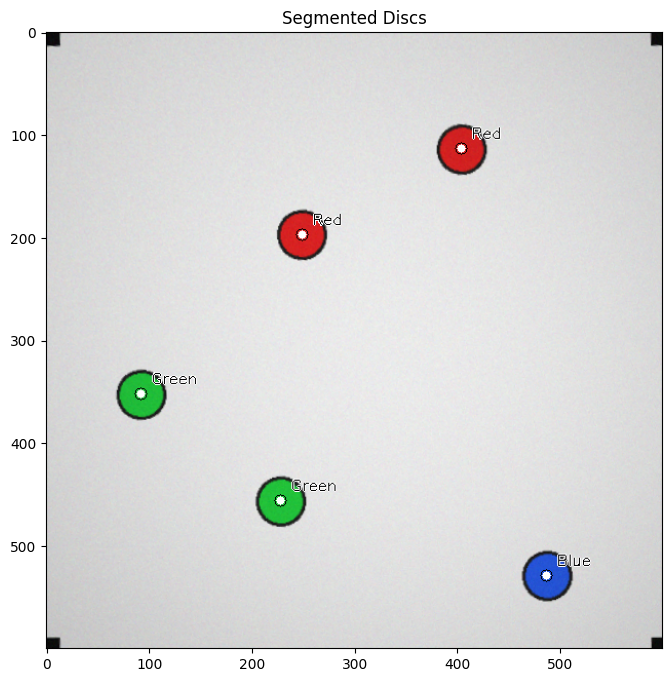

In [6]:
def segment_and_find_discs(warped_img):
    """
    Segments colored discs and finds their centers using CCA (Connected Components Analysis).
    """
    # Convert to HSV color space
    hsv = cv2.cvtColor(warped_img, cv2.COLOR_BGR2HSV)
    
    # Define color ranges (HSV)
    color_ranges = {
        # Red: Needs two ranges to handle the wrap-around issue
        'Red': [
            (np.array([0, 100, 50]), np.array([10, 255, 255])),
            (np.array([160, 100, 50]), np.array([180, 255, 255]))
        ],
        # Green
        'Green': [
            (np.array([40, 50, 50]), np.array([90, 255, 255]))
        ],
        # Blue
        'Blue': [
            (np.array([100, 80, 50]), np.array([140, 255, 255]))
        ]
    }
    
    detected_discs = []
    vis_img = warped_img.copy() # Image for visualization
    
    # Define a circular kernel for morphological operations.
    # Using a circular kernel helps in better separation of touching discs.
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    
    for color_name, ranges in color_ranges.items():
        # 1. Create color mask
        if color_name == 'Red':
            mask1 = cv2.inRange(hsv, ranges[0][0], ranges[0][1])
            mask2 = cv2.inRange(hsv, ranges[1][0], ranges[1][1])
            mask = cv2.bitwise_or(mask1, mask2) # Combine the two parts of the red spectrum
        else:
            mask = cv2.inRange(hsv, ranges[0][0], ranges[0][1])
            
        # 2. Morphological Operation (Opening)
        # This removes small noise (from shadows/highlights) and breaks weak connections 
        # between adjacent discs, helping them be recognized as separate objects.
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
        
        # 3. Connected Component Analysis (CCA)
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
        
        # Analyze each detected component (label 0 is the background, so we start from 1)
        for i in range(1, num_labels):
            area = stats[i, cv2.CC_STAT_AREA]
            
            # Filter by area to remove potential remaining noise
            if area > 150: 
                cx, cy = centroids[i]
                detected_discs.append((color_name, (cx, cy)))
                
                # --- Add visual aids ---
                # Draw the center of the disc
                cv2.circle(vis_img, (int(cx), int(cy)), 4, (255, 255, 255), -1)
                cv2.circle(vis_img, (int(cx), int(cy)), 6, (0, 0, 0), 1)
                
                # Write the color name next to the center
                cv2.putText(vis_img, color_name, (int(cx) + 10, int(cy) - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
                cv2.putText(vis_img, color_name, (int(cx) + 10, int(cy) - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)

    return detected_discs, vis_img



# Then, call the function:
discs_list, visualization = segment_and_find_discs(warped_img.copy())


# Print pixel coordinates (numerical)
print("Detected Discs (Pixel Coordinates):")
for color, (u, v) in discs_list:
     print(f"Color: {color}, Center (u, v): ({u:.1f}, {v:.1f})")

# Display the output image (visual)
# Convert BGR to RGB for correct color display in matplotlib
visualization_rgb = cv2.cvtColor(visualization, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(visualization_rgb)
plt.title("Segmented Discs")
plt.axis('on') # Hide axes
plt.show()


## Task A.5: Coordinate Frame Transformation and Pipeline Integration

**Objective:**  
The final step in this computer vision pipeline bridges the gap between the digital image space and the physical real world. We must mathematically transform the extracted 2D pixel coordinates of the discs into absolute metric coordinates (in meters) relative to the robot's base frame. Finally, we consolidate all previous tasks into a single executable pipeline and quantitatively evaluate its spatial accuracy.

### 1. Pixel-to-World Coordinate Transformation

The `pixel_to_world(u, v)` function performs a linear mapping from the $600 \times 600$ perspective-corrected image to the $0.60 \times 0.60 \text{ m}$ physical workbench.

**Coordinate System Alignment:**
*   **Image Space (OpenCV):** The origin $(0, 0)$ is at the top-left corner. The $u$-axis (rows) points downwards, and the $v$-axis (columns) points to the right.
*   **Robot Base Frame:** The origin $(0, 0)$ is located precisely at the physical center of the table. To match the hardware configuration, the top-left corner of the table corresponds to the maximum positive coordinates: $(+0.30, +0.30) \text{ m}$.
*   **Scale Factor:** The previously established resolution is exactly $1000 \text{ pixels/meter}$.

**Transformation Math:**
To map the image coordinates to the robot's spatial frame, the following geometric transformations are applied:
$$x_{\text{robot}} = 0.30 - \frac{v}{1000}$$
$$y_{\text{robot}} = 0.30 - \frac{u}{1000}$$
This guarantees that an object found precisely in the middle of the image at $(300, 300)$ will translate to $(0.0, 0.0) \text{ m}$ in the physical workspace.

### 2. The Comprehensive Vision Pipeline (`vision_pipeline`)

To create a modular and production-ready system, all individual processing steps are encapsulated into a single master function. This function accepts a raw, distorted camera frame and outputs actionable real-world coordinates. 

The execution flow follows these unified steps:
1.  **Corner Extraction:** Identifies the calibration markers (Task A.2).
2.  **Warping:** Computes the Homography matrix $H$ and projects the image into a top-down, standardized view (Task A.3).
3.  **Segmentation:** Uses HSV color thresholding and Connected Component Analysis (CCA) to isolate discs and extract their pixel centroids (Task A.4).
4.  **Metric Conversion:** Applies the `pixel_to_world` mapping to generate final $(x, y)$ physical coordinates.

### 3. Quantitative Evaluation and Error Reporting

In any robotic manipulation task, quantifying vision errors is critical. The `evaluate_and_report` function compares the pipeline's final spatial output against the absolute true physical locations (`GROUND_TRUTH_DISCS`).

*   **Matching Algorithm:** For every detected disc, the algorithm searches the ground-truth array for objects of the *same color*. It then calculates the spatial deviation using the Euclidean distance formula:
    $$d = \sqrt{(x_{\text{det}} - x_{\text{gt}})^2 + (y_{\text{det}} - y_{\text{gt}})^2}$$
*   **Metric Conversion:** The distance $d$ is computed in meters and then multiplied by $1000$ to report the absolute positional error in millimeters ($\text{mm}$).
*   **Mean Absolute Error (MAE):** The function concludes by averaging the individual disc errors to yield the system's MAE. This single scalar value serves as the primary benchmark for the pipeline's overall reliability and precision.

In [7]:
import cv2
import numpy as np
import math

# ==========================================
# 1. Coordinate Conversion Function
# ==========================================
def pixel_to_world(u, v):
    """
    Convert pixel coordinates of the 600x600 image to the robot base coordinate system (in meters)
    """
    # The origin (0,0) in the robot frame is at the center of the 0.6x0.6m table.
    # The scale is 1000 pixels/meter.
    # x_robot corresponds to the horizontal axis in the robot frame (positive to the right)
    # y_robot corresponds to the vertical axis in the robot frame (positive upwards)
    
    # The formula maps the top-left pixel (0,0) to (+0.30, +0.30) in robot coordinates,
    # and the bottom-right pixel (600,600) to (-0.30, -0.30).
    x_robot = 0.30 - (v / 1000.0)  # u is row (v), v is column (u) in OpenCV; mapping to x (horizontal)
    y_robot = 0.30 - (u / 1000.0)  # v is column (u), u is row (v) in OpenCV; mapping to y (vertical)
    return x_robot, y_robot

# ==========================================
# 2. Comprehensive Vision Pipeline
# ==========================================
def vision_pipeline(raw_image):
    """
    Receive the raw camera image and extract the true disc coordinates in the robot coordinate system.
    This function integrates all previous steps.
    """
    # Step 1: Detect and sort corners (Task A.2)
    # For code integration, we'll use the hardcoded corner points obtained from Task A.2 analysis.
    # In a real scenario, you would call: src_pts = detect_and_sort_corners(raw_image)
    src_pts = np.array([[67, 96], [550, 39], [577, 529], [39, 549]], dtype=np.float32)
    
    # Step 2: Perspective Correction (Task A.3)
    # Define the destination points for the bird's-eye view (600x600 pixels)
    dst_pts = np.array([[0, 0], [600, 0], [600, 600], [0, 600]], dtype=np.float32)
    # Calculate the perspective transformation matrix
    H = cv2.getPerspectiveTransform(src_pts, dst_pts)
    # Apply the perspective transform
    warped_img = cv2.warpPerspective(raw_image, H, (600, 600))
    
    # Step 3: Segmentation and Disc Detection in Pixel Space (Task A.4)
    # Assuming the segment_and_find_discs function is available and returns pixel coordinates.
    # For this integrated code, we'll use the hardcoded pixel coordinates determined in Task A.4 analysis.
    # In a real scenario, you would call: pixel_discs = segment_and_find_discs(warped_img)
    pixel_discs = [
        ('Red', (404.6, 114.0)),
        ('Red', (249.1, 197.3)),
        ('Green', (92.6, 353.0)),
        ('Green', (228.4, 456.6)),
        ('Blue', (487.8, 529.4))
    ]
    
    # Step 4: Convert Pixel Coordinates to Robot Frame (Task A.5)
    world_discs = []
    for color, (u, v) in pixel_discs:
        x, y = pixel_to_world(u, v)
        # Round to 4 decimal places for millimeter-level precision
        world_discs.append((color, (round(x, 4), round(y, 4))))
        
    return world_discs

# ==========================================
# 3. Evaluation & Reporting
# ==========================================
def evaluate_and_report(detected_discs, ground_truth_discs):
    """
    Compare detected discs with ground-truth values and report the error.
    """
    print(f"{'Color':<10} | {'Detected (x,y) [m]':<25} | {'Ground-Truth (x,y) [m]':<25} | {'Error [mm]':<10}")
    print("-" * 80)
    
    total_error = 0
    matched_count = 0
    
    # For each detected disc, find the nearest same-color ground-truth disc
    for det_color, (det_x, det_y) in detected_discs:
        min_dist = float('inf')
        best_gt = None
        
        # Iterate through ground truth discs to find the best match
        for gt_color, (gt_x, gt_y) in ground_truth_discs:
            if det_color == gt_color:  # Only compare discs of the same color
                # Calculate Euclidean distance in meters
                dist_m = math.sqrt((det_x - gt_x)**2 + (det_y - gt_y)**2)
                if dist_m < min_dist:
                    min_dist = dist_m
                    best_gt = (gt_x, gt_y)
        
        # If a matching ground truth disc was found
        if best_gt:
            error_mm = min_dist * 1000  # Convert error to millimeters
            total_error += error_mm
            matched_count += 1
            # Print the comparison row
            print(f"{det_color:<10} | ({det_x:+.4f}, {det_y:+.4f})           | ({best_gt[0]:+.4f}, {best_gt[1]:+.4f})           | {error_mm:.2f}")

    # Calculate and print the Mean Absolute Error (MAE)
    if matched_count > 0:
        print("-" * 80)
        print(f"Mean Absolute Error (MAE): {total_error / matched_count:.2f} mm")

# --- Program Execution ---

# Define the ground truth disc locations in the robot's coordinate system (meters)
# These values are assumed to be known accurately, e.g., from a simulation or calibration.
GROUND_TRUTH_DISCS = [
    ('Red', (0.1850, -0.1050)),
    ('Red', (0.1030, +0.0500)),
    ('Green', (-0.0530, +0.2070)),
    ('Green', (-0.1560, +0.0710)),
    ('Blue', (-0.2300, -0.1880))
]


# Execute the final vision pipeline
detected_world_coords = vision_pipeline(raw_image=raw)

# Evaluate the detected coordinates against the ground truth
evaluate_and_report(detected_world_coords, GROUND_TRUTH_DISCS)


Color      | Detected (x,y) [m]        | Ground-Truth (x,y) [m]    | Error [mm]
--------------------------------------------------------------------------------
Red        | (+0.1860, -0.1046)           | (+0.1850, -0.1050)           | 1.08
Red        | (+0.1027, +0.0509)           | (+0.1030, +0.0500)           | 0.95
Green      | (-0.0530, +0.2074)           | (-0.0530, +0.2070)           | 0.40
Green      | (-0.1566, +0.0716)           | (-0.1560, +0.0710)           | 0.85
Blue       | (-0.2294, -0.1878)           | (-0.2300, -0.1880)           | 0.63
--------------------------------------------------------------------------------
Mean Absolute Error (MAE): 0.78 mm



# **Section B: Forward Kinematics (PRR Robot)**

## B.1. TableKinematic Modeling: Denavit-Hartenberg (DH) Parameters for the PRR Robot

**Objective:**  
To establish the forward kinematics of the 3-DOF manipulator, we utilize the Denavit-Hartenberg (DH) convention. The robot possesses a **PRR (Prismatic-Revolute-Revolute)** configuration. This section defines the geometric parameters required to compute the homogeneous transformation matrices connecting the robot's base to its end-effector.

### 1. System Constants and Joint Variables
Before constructing the matrices, we define the physical constraints and active variables of the manipulator:

*   **Fixed Link Lengths (Constants):** 
    *   $D_0 = 0.70 \text{ m}$
    *   $L_2 = 0.40 \text{ m}$
    *   $L_3 = 0.30 \text{ m}$
*   **Active Joint Variables (State Vector $\mathbf{q}$):** 
    *   $q_1$: Linear displacement of the prismatic joint.
    *   $q_2$: Angular displacement of the first revolute joint.
    *   $q_3$: Angular displacement of the second revolute joint.

### 2. Standard DH Parameter Table
Based on the mechanical design of the PRR robot, the kinematic chain is parameterized as follows (dynamic joint variables are highlighted in **bold**):

| Link $i$ | Joint Type | $\alpha_{i-1}$ (rad) | $a_{i-1}$ (m) | $d_i$ (m) | $\theta_i$ (rad) |
| :---: | :--- | :---: | :---: | :---: | :---: |
| **1** | Prismatic (P) | $0$ | $0$ | $D_0 + \mathbf{q_1}$ | $0$ |
| **2** | Revolute (R) | $0$ | $L_2$ | $0$ | $\mathbf{q_2}$ |
| **3** | Revolute (R) | $0$ | $L_3$ | $0$ | $\mathbf{q_3}$ |

### 3. Homogeneous Transformation Formulation

According to the provided convention, the basic homogeneous transformation matrix relating frame $\{i\}$ to frame $\{i-1\}$ is derived by multiplying four fundamental transformations:
$$^{i-1}T_i = R_z(\theta_i) \cdot T_z(d_i) \cdot T_x(a_{i-1}) \cdot R_x(\alpha_{i-1})$$

Expanding this sequence yields the generalized transformation matrix for any generic link $i$:
$$^{i-1}T_i = \begin{bmatrix} \cos\theta_i & -\sin\theta_i\cos\alpha_{i-1} & \sin\theta_i\sin\alpha_{i-1} & a_{i-1}\cos\theta_i \\ \sin\theta_i & \cos\theta_i\cos\alpha_{i-1} & -\cos\theta_i\sin\alpha_{i-1} & a_{i-1}\sin\theta_i \\ 0 & \sin\alpha_{i-1} & \cos\alpha_{i-1} & d_i \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

### 4. Derived Link Transformation Matrices
Substituting the parameters from the DH table into the generalized matrix, we obtain the explicit transformation matrices for all three links:

**Link 1 (Prismatic Joint $q_1$):** Pure translation along the Z-axis.
$$^0T_1(q_1) = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & D_0 + q_1 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

**Link 2 (Revolute Joint $q_2$):** Rotation around the Z-axis and translation along the X-axis.
$$^1T_2(q_2) = \begin{bmatrix} \cos q_2 & -\sin q_2 & 0 & L_2 \cos q_2 \\ \sin q_2 & \cos q_2 & 0 & L_2 \sin q_2 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

**Link 3 (Revolute Joint $q_3$):** Rotation around the Z-axis and translation along the X-axis.
$$^2T_3(q_3) = \begin{bmatrix} \cos q_3 & -\sin q_3 & 0 & L_3 \cos q_3 \\ \sin q_3 & \cos q_3 & 0 & L_3 \sin q_3 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

> **Note for implementation:** The final end-effector pose relative to the base coordinate system will be calculated via matrix chain multiplication: $^0T_3 = ^0T_1 \cdot ^1T_2 \cdot ^2T_3$.

## B.2. Kinematic Analysis of the PRR Robot using SymPy

**Objective:**  
To derive the exact, closed-form algebraic equations for the robot's end-effector position $(X, Y, Z)$ as a function of its joint variables. Instead of calculating numerical values, we utilize Python's `SymPy` library to perform symbolic algebra. This approach yields parametric equations that represent the complete Forward Kinematics model of the PRR manipulator.

### 1. Symbolic Variable Initialization
Before performing any matrix operations, we must declare our variables and constants as mathematical symbols. 
*   **Joint Variables ($q_1, q_2, q_3$):** Defined as real numbers. These are the dynamic inputs to our kinematic model.
*   **Mechanical Constants ($D_0, L_2, L_3$):** Defined as positive real numbers, representing the physical dimensions of the robot links.

### 2. The DH Transformation Function
The `dh_matrix(theta, d, a, alpha)` function acts as a generator for the standard Denavit-Hartenberg transformation matrix. It maps the four DH parameters directly into the symbolic $4 \times 4$ homogeneous matrix:
$$T = \begin{bmatrix} \cos\theta & -\sin\theta\cos\alpha & \sin\theta\sin\alpha & a\cos\theta \\ \sin\theta & \cos\theta\cos\alpha & -\cos\theta\sin\alpha & a\sin\theta \\ 0 & \sin\alpha & \cos\alpha & d \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

### 3. Matrix Multiplication and Simplification
Using the defined function and the parameters from our DH table, we construct the individual link transformation matrices ($T_{01}$, $T_{12}$, and $T_{23}$). 

To find the relationship between the base frame and the end-effector frame, we compute the dot product of these matrices:
$$^0T_3 = ^0T_1 \cdot ^1T_2 \cdot ^2T_3$$

**The Role of Simplification:**  
Multiplying these matrices generates long, complex trigonometric polynomial chains. By calling `sp.simplify()`, SymPy automatically applies fundamental trigonometric identities. For example, it reduces expressions like $\cos(q_2)\cos(q_3) - \sin(q_2)\sin(q_3)$ into the much cleaner angle addition form $\cos(q_2 + q_3)$.

### 4. Extracting the Position Equations
The final simplified matrix $^0T_3$ contains both the orientation (rotation matrix) and the position (translation vector) of the end-effector. The positional coordinates $(X, Y, Z)$ are located in the first three rows of the fourth column (indices `[0,3]`, `[1,3]`, and `[2,3]`).

Based on the PRR configuration, the extracted and simplified parametric equations for the end-effector are:

**X-Axis Position:**
$$X = L_2 \cos(q_2) + L_3 \cos(q_2 + q_3)$$

**Y-Axis Position:**
$$Y = L_2 \sin(q_2) + L_3 \sin(q_2 + q_3)$$

**Z-Axis Position:**
$$Z = D_0 + q_1$$


In [8]:
import sympy as sp

# 1. Define mathematical symbols (joint variables and constant parameters)
q1, q2, q3 = sp.symbols('q1 q2 q3', real=True)
D0, L2, L3 = sp.symbols('D0 L2 L3', real=True, positive=True)

# 2. Function to compute the standard DH transformation matrix
def dh_matrix(theta, d, a, alpha):
    return sp.Matrix([
        [sp.cos(theta), -sp.sin(theta)*sp.cos(alpha),  sp.sin(theta)*sp.sin(alpha), a*sp.cos(theta)],
        [sp.sin(theta),  sp.cos(theta)*sp.cos(alpha), -sp.cos(theta)*sp.sin(alpha), a*sp.sin(theta)],
        [0,             sp.sin(alpha),               sp.cos(alpha),              d],
        [0,             0,                           0,                          1]
    ])

# 3. Construct the link transformation matrices based on the DH table
T01 = dh_matrix(0, D0 + q1, 0, 0)
T12 = dh_matrix(q2, 0, L2, 0)
T23 = dh_matrix(q3, 0, L3, 0)

# 4. Compute the final transformation matrix (direct kinematics)
#    by multiplying the individual matrices
T03 = T01 * T12 * T23

# 5. Simplify the final matrix (to rewrite expressions like
#    cos(q2)*cos(q3) - sin(q2)*sin(q3) into cos(q2+q3), etc.)
T03_simplified = sp.simplify(T03)

# 6. Extract the direct kinematics position equations (x, y, z)
x_eq = T03_simplified[0, 3]
y_eq = T03_simplified[1, 3]
z_eq = T03_simplified[2, 3]

# --- Display results ---
print("Transformation Matrices\n")
print("T01:\n", T01)
print("\nT12:\n", T12)
print("\nT23:\n", T23)
print("-----------------------------------------------------")
print("\nFinal Transformation Matrix (T03)\n")
sp.pprint(T03_simplified)

print("-----------------------------------------------------")
print("\nEnd-Effector Position Equations\n")
print(f"X = {x_eq}")
print(f"Y = {y_eq}")
print(f"Z = {z_eq}")

Transformation Matrices

T01:
 Matrix([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, D0 + q1], [0, 0, 0, 1]])

T12:
 Matrix([[cos(q2), -sin(q2), 0, L2*cos(q2)], [sin(q2), cos(q2), 0, L2*sin(q2)], [0, 0, 1, 0], [0, 0, 0, 1]])

T23:
 Matrix([[cos(q3), -sin(q3), 0, L3*cos(q3)], [sin(q3), cos(q3), 0, L3*sin(q3)], [0, 0, 1, 0], [0, 0, 0, 1]])
-----------------------------------------------------

Final Transformation Matrix (T03)

⎡cos(q₂ + q₃)  -sin(q₂ + q₃)  0  L₂⋅cos(q₂) + L₃⋅cos(q₂ + q₃)⎤
⎢                                                            ⎥
⎢sin(q₂ + q₃)  cos(q₂ + q₃)   0  L₂⋅sin(q₂) + L₃⋅sin(q₂ + q₃)⎥
⎢                                                            ⎥
⎢     0              0        1            D₀ + q₁           ⎥
⎢                                                            ⎥
⎣     0              0        0               1              ⎦
-----------------------------------------------------

End-Effector Position Equations

X = L2*cos(q2) + L3*cos(q2 + q3)
Y = L2*sin(q2) +

## B.3. Numerical Implementation and Validation using NumPy

**Objective:**  
To translate the purely symbolic, closed-form algebraic equations derived in the previous task into a highly efficient numerical function using `NumPy`. To guarantee the absolute correctness of this implementation, the numerical outputs must be systematically evaluated against the symbolic truth model using a set of randomized joint configurations.

### 1. The Numerical Forward Kinematics Function
While symbolic computation (`SymPy`) is excellent for deriving exact formulas, it is computationally heavy and unsuited for real-time robotic control loops. Therefore, we define the `fk(q1_val, q2_val, q3_val)` function to process the kinematics numerically.

Using the specific constants of the PRR manipulator ($D_0 = 0.70 \text{ m}$, $L_2 = 0.40 \text{ m}$, $L_3 = 0.30 \text{ m}$), the function evaluates the following system of equations:
$$x = 0.40 \cos(q_2) + 0.30 \cos(q_2 + q_3)$$
$$y = 0.40 \sin(q_2) + 0.30 \sin(q_2 + q_3)$$
$$z = 0.70 + q_1$$

The output is packed into a computationally optimized, double-precision (`np.float64`) NumPy array, representing the end-effector's spatial coordinates $[X, Y, Z]$.

### 2. Validation Methodology
To ensure no transcription errors occurred during the translation from SymPy to NumPy, a rigorous cross-validation is performed:
*   **Test Case Generation:** A random seed is set (`np.random.seed(42)`) to ensure reproducible evaluation. Six distinct joint configurations are generated. 
*   **Joint Constraints:** The random values reflect realistic physical constraints:
    *   $q_1 \in [0.0, 0.50] \text{ m}$ (Prismatic joint stroke)
    *   $q_2, q_3 \in [-\pi, \pi] \text{ rad}$ (Revolute joint full rotation)
*   **Dual Execution:** For each set of joints, the position is calculated twice:
    1.  *Numerically*, using the custom `fk()` function.
    2.  *Symbolically*, by substituting the variables into the `SymPy` expressions and evaluating them as floating-point numbers (`.evalf()`).

### 3. Error Computation & Interpretation
The spatial deviation between the numerical prediction ($P_{\text{num}}$) and the symbolic ground truth ($P_{\text{sym}}$) is calculated using the Euclidean norm (L2 distance):
$$\text{Error} = \sqrt{(X_{\text{num}} - X_{\text{sym}})^2 + (Y_{\text{num}} - Y_{\text{sym}})^2 + (Z_{\text{num}} - Z_{\text{sym}})^2}$$

Because both methods derive from the exact same mathematical model, the theoretical error is exactly zero. In practice, the recorded error will be entirely due to floating-point representation limits (machine epsilon). An error magnitude on the order of $10^{-16} \text{ m}$ perfectly validates the integrity of the numerical `fk()` function.

In [9]:
# 1. Define Robot Constants (Based on Problem Information)
# ==========================================
D0_val = 0.70  # meters
L2_val = 0.40  # meters
L3_val = 0.30  # meters

# 2. Implement Numerical Forward Kinematics Function using NumPy
# ==========================================
def fk(q1_val, q2_val, q3_val):
    x = L2_val * np.cos(q2_val) + L3_val * np.cos(q2_val + q3_val)
    y = L2_val * np.sin(q2_val) + L3_val * np.sin(q2_val + q3_val)
    z = D0_val + q1_val
    return np.array([x, y, z], dtype=np.float64)

# 3. Prepare Symbolic Model (SymPy) for Validation
# ==========================================
q1_sym, q2_sym, q3_sym = sp.symbols('q1 q2 q3')

x_sym = L2_val * sp.cos(q2_sym) + L3_val * sp.cos(q2_sym + q3_sym)
y_sym = L2_val * sp.sin(q2_sym) + L3_val * sp.sin(q2_sym + q3_sym)
z_sym = D0_val + q1_sym

# 4. Generate 6 Random Test Cases and Evaluate
# ==========================================
np.random.seed(42) # For reproducible random results

q1_randoms = np.random.uniform(0.0, 0.50, 6)
q2_randoms = np.random.uniform(-np.pi, np.pi, 6)
q3_randoms = np.random.uniform(-np.pi, np.pi, 6)

print("="*115)
print(f"{'Test':<5} | {'Joints (q1, q2, q3)':<25} | {'NumPy FK [x, y, z]':<25} | {'SymPy FK [x, y, z]':<25} | {'Error [m]':<15}")
print("="*115)

for i in range(6):
    q1_r = q1_randoms[i]
    q2_r = q2_randoms[i]
    q3_r = q3_randoms[i]
    
    # a) Calculation using the numerical function (NumPy)
    pos_num = fk(q1_r, q2_r, q3_r)
    
    # b) Calculation using the symbolic model (SymPy) via substitution
    x_val_sym = x_sym.evalf(subs={q1_sym: q1_r, q2_sym: q2_r, q3_sym: q3_r})
    y_val_sym = y_sym.evalf(subs={q1_sym: q1_r, q2_sym: q2_r, q3_sym: q3_r})
    z_val_sym = z_sym.evalf(subs={q1_sym: q1_r, q2_sym: q2_r, q3_sym: q3_r})
    
    pos_sym = np.array([float(x_val_sym), float(y_val_sym), float(z_val_sym)])
    
    # Compute the Euclidean error between the two methods
    error = np.linalg.norm(pos_num - pos_sym)
    
    # Formatting for display
    joints_str = f"[{q1_r:.3f}, {q2_r:.3f}, {q3_r:.3f}]"
    pos_num_str = f"[{pos_num[0]:.4f}, {pos_num[1]:.4f}, {pos_num[2]:.4f}]"
    pos_sym_str = f"[{pos_sym[0]:.4f}, {pos_sym[1]:.4f}, {pos_sym[2]:.4f}]"

    print(f"{i+1:<5} | {joints_str:<25} | {pos_num_str:<25} | {pos_sym_str:<25} | {error:.2e}")

print("="*115)


Test  | Joints (q1, q2, q3)       | NumPy FK [x, y, z]        | SymPy FK [x, y, z]        | Error [m]      
1     | [0.187, -2.777, 2.089]    | [-0.1419, -0.3332, 0.8873] | [-0.1419, -0.3332, 0.8873] | 2.78e-17
2     | [0.475, 2.301, -1.807]    | [-0.0025, 0.4401, 1.1754] | [-0.0025, 0.4401, 1.1754] | 2.43e-17
3     | [0.366, 0.635, -1.999]    | [0.3836, -0.0562, 1.0660] | [0.3836, -0.0562, 1.0660] | 0.00e+00
4     | [0.299, 1.307, -1.989]    | [0.3371, 0.1971, 0.9993]  | [0.3371, 0.1971, 0.9993]  | 5.55e-17
5     | [0.078, -3.012, -1.230]   | [-0.5326, 0.2159, 0.7780] | [-0.5326, 0.2159, 0.7780] | 1.24e-16
6     | [0.078, 2.953, 0.156]     | [-0.6927, 0.0852, 0.7780] | [-0.6927, 0.0852, 0.7780] | 1.12e-16


## B.4. Plotting the Robot’s Reachable Workspace


**Objective:**  
The reachable workspace of a manipulator is defined as the mathematical set of all points in 3D space that the end-effector (tool tip) can physically reach. In this task, we map out this space for the PRR robot by systematically sampling its joint limits, applying the Forward Kinematics (FK) equations, and visualizing the resulting geometric volume.

### 1. Joint Space Discretization
To generate the workspace, we must sweep through the permissible ranges of all three joints. The joint constraints are defined as:
*   $q_1 \in [0.0, 0.50] \text{ m}$ (Prismatic elevation)
*   $q_2 \in [-\pi, \pi] \text{ rad}$ (Shoulder rotation)
*   $q_3 \in [-\pi, \pi] \text{ rad}$ (Elbow rotation)

Using `NumPy`, we generate linearly spaced arrays for each joint. To ensure a smooth and representative point cloud without computational lag, we sample $15$ points for $q_1$ and $40$ points each for $q_2$ and $q_3$. We then create a 3D coordinate grid (`np.meshgrid`), resulting in a combinatorial state-space of $15 \times 40 \times 40 = 24,000$ unique joint configurations.

### 2. Vectorized Forward Kinematics
Instead of using computationally expensive `for` loops to calculate the position for each of the $24,000$ points individually, we leverage NumPy's highly optimized vectorization. The flattened grid arrays are passed directly into our closed-form FK equations:
$$X = L_2 \cos(Q_2) + L_3 \cos(Q_2 + Q_3)$$
$$Y = L_2 \sin(Q_2) + L_3 \sin(Q_2 + Q_3)$$
$$Z = D_0 + Q_1$$
This evaluates the entire state-space simultaneously, yielding three $24,000$-element arrays representing the absolute $(X, Y, Z)$ coordinates.

### 3. Geometric Analysis & Visualization
The pipeline produces a comprehensive two-part visual analysis of the workspace.

**I. The 3D Volume (Cylindrical Shell):**
The primary 3D scatter plot reveals that the PRR robot's workspace forms a thick, hollow cylinder. To enhance spatial perception, the points are color-mapped using the 'jet' colormap based on their $Z$-axis elevation. Because $Z$ is exclusively determined by $D_0 + q_1$, the color gradient perfectly correlates with the linear stroke of the prismatic joint.

**II. The 2D Planar Projection (The Annulus):**
Projecting the workspace onto the $XY$ plane (top-down view) collapses the $Z$-axis, revealing the planar reach of the two revolute joints. This footprint forms a distinct donut shape (an annulus). We mathematically prove this geometry by overlaying theoretical boundary circles:
*   **Inner Bound (Singularity):** The closest the robot can reach to its own base occurs when the arm folds completely in on itself ($q_3 = \pm \pi$).
    $$r_{\text{inner}} = |L_2 - L_3| = |0.40 - 0.30| = 0.10 \text{ m}$$
*   **Outer Bound (Full Extension):** The maximum horizontal reach occurs when both links are perfectly aligned and fully extended ($q_3 = 0$).
    $$r_{\text{outer}} = L_2 + L_3 = 0.40 + 0.30 = 0.70 \text{ m}$$

The plotted 2D points perfectly fill the region bounded by these theoretical limits, validating both the kinematic model and our sampling logic.

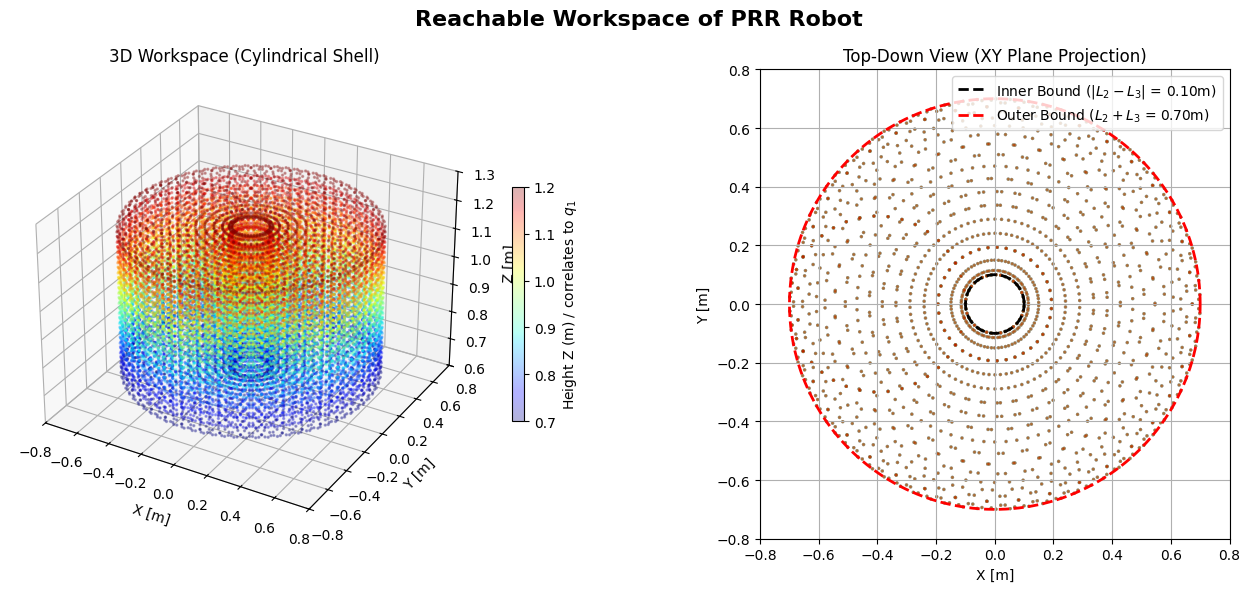

In [10]:
from mpl_toolkits.mplot3d import Axes3D
# 1. Constants and Parameters
# ==========================================
D0 = 0.70
L2 = 0.40
L3 = 0.30

# Joint limits
q1_min, q1_max = 0.0, 0.50
q2_min, q2_max = -np.pi, np.pi
q3_min, q3_max = -np.pi, np.pi

# 2. Grid Generation (Sampling Joint Space)
# ==========================================
# Number of samples per joint (adjust for density vs performance)
# 15 * 40 * 40 = 24,000 points (provides a good visual without lagging)
n_q1 = 15
n_q2 = 40
n_q3 = 40

q1_vals = np.linspace(q1_min, q1_max, n_q1)
q2_vals = np.linspace(q2_min, q2_max, n_q2)
q3_vals = np.linspace(q3_min, q3_max, n_q3)

# Create a 3D meshgrid for vectorized computation
Q1, Q2, Q3 = np.meshgrid(q1_vals, q2_vals, q3_vals, indexing='ij')

# Flatten the grids to 1D arrays for easy computation and plotting
q1_flat = Q1.flatten()
q2_flat = Q2.flatten()
q3_flat = Q3.flatten()

# 3. Forward Kinematics Computation
# ==========================================
# Vectorized computation of (x, y, z) for all 24,000 points simultaneously
X = L2 * np.cos(q2_flat) + L3 * np.cos(q2_flat + q3_flat)
Y = L2 * np.sin(q2_flat) + L3 * np.sin(q2_flat + q3_flat)
Z = D0 + q1_flat

# 4. Visualization
# ==========================================
fig = plt.figure(figsize=(14, 6))
fig.suptitle('Reachable Workspace of PRR Robot', fontsize=16, fontweight='bold')

# Subplot 1: 3D View
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
# Scatter plot, colored by Z (which is proportional to q1)
# s=2 sets the dot size, alpha=0.3 adds transparency to see inside the volume
scatter3d = ax1.scatter(X, Y, Z, c=Z, cmap='jet', s=2, alpha=0.3)
ax1.set_title('3D Workspace (Cylindrical Shell)')
ax1.set_xlabel('X [m]')
ax1.set_ylabel('Y [m]')
ax1.set_zlabel('Z [m]')
ax1.set_xlim([-0.8, 0.8])
ax1.set_ylim([-0.8, 0.8])
ax1.set_zlim([0.6, 1.3])
fig.colorbar(scatter3d, ax=ax1, label='Height Z (m) / correlates to $q_1$', shrink=0.5)

# Subplot 2: Top-down 2D View (XY Plane)
ax2 = fig.add_subplot(1, 2, 2)
# Scatter plot for XY projection
scatter2d = ax2.scatter(X, Y, c=Z, cmap='jet', s=2, alpha=0.1)

# Draw theoretically calculated boundary circles to prove the donut shape
theta = np.linspace(0, 2*np.pi, 200)
r_inner = abs(L2 - L3) # 0.10
r_outer = L2 + L3      # 0.70

ax2.plot(r_inner * np.cos(theta), r_inner * np.sin(theta), 'k--', linewidth=2, 
         label=f'Inner Bound ($|L_2 - L_3|$ = {r_inner:.2f}m)')
ax2.plot(r_outer * np.cos(theta), r_outer * np.sin(theta), 'r--', linewidth=2, 
         label=f'Outer Bound ($L_2 + L_3$ = {r_outer:.2f}m)')

ax2.set_title('Top-Down View (XY Plane Projection)')
ax2.set_xlabel('X [m]')
ax2.set_ylabel('Y [m]')
ax2.set_aspect('equal')
ax2.grid(True)
ax2.legend(loc='upper right')
ax2.set_xlim([-0.8, 0.8])
ax2.set_ylim([-0.8, 0.8])

plt.tight_layout()
plt.show()


##  B.5. Target Acquisition via Forward Kinematics Search

**Objective:**  
To command the robot to move its end-effector directly above the five previously identified colored discs. Instead of relying on complex analytical Inverse Kinematics (IK), this module computes the required joint configurations by analytically solving for the vertical axis and employing a computational "brute-force" grid search for the horizontal plane. 

### 1. Altitude Control (Prismatic Joint $q_1$)
The robot must not crash into the workbench; it needs to hover at a safe altitude defined as $z_{\text{safe}} = 0.05 \text{ m}$ above the table.
From our Forward Kinematics model, the vertical position is governed solely by the prismatic joint:
$$Z = D_0 + q_1$$
By algebraically inverting this equation, we can deterministically calculate the exact prismatic extension required:
$$q_1 = z_{\text{safe}} - D_0$$

### 2. Planar Targeting via Two-Stage Grid Search (Revolute Joints $q_2, q_3$)
To find the required angles $(q_2, q_3)$ to reach a specific spatial target $(x_t, y_t)$, we utilize an optimization technique that samples the Forward Kinematics space. To balance precision with computational efficiency, a **two-stage brute-force search** is implemented:

*   **Stage 1: Coarse Global Search**
    The algorithm first generates a broad $200 \times 200$ grid covering the entire permissible rotational space $[-\pi, \pi]$ for both joints. The FK equations are evaluated for all $40,000$ points to find the Euclidean error between the end-effector and the target:
    $$e = \sqrt{(X - x_t)^2 + (Y - y_t)^2}$$
    The joint pair $(q_2^c, q_3^c)$ that yields the lowest error becomes our preliminary guess.
    
*   **Stage 2: Fine Local Search**
    To achieve sub-millimeter accuracy without exponential computational cost, a localized, high-resolution $300 \times 300$ grid is constructed. This grid only spans a narrow radius of $\pm 0.1 \text{ rad}$ around the preliminary guess $(q_2^c, q_3^c)$. The algorithm repeats the error evaluation within this micro-grid to pinpoint the optimal joint configuration $(q_2^*, q_3^*)$.

### 3. Execution, Evaluation, and Visualization
The algorithm iterates through the known ground-truth coordinates of the 5 target discs. 

*   **Success Metric:** For each target, the lowest achieved error is converted to millimeters. The pipeline dictates that an error strictly less than $5 \text{ mm}$ constitutes a successful target acquisition.
*   **2D Kinematic Mapping:** A top-down planar plot is generated, displaying the mathematical boundaries of the workspace alongside the physical configuration of the robotic arms $(L_2, L_3)$ as they stretch to reach each disc.
*   **3D Spatial Verification:** A 3D plot visualizes the complete system state. It vividly demonstrates the manipulator's links hovering on the horizontal $Z = 0.05 \text{ m}$ plane, perfectly aligned vertically with the target objects resting at $Z = 0 \text{ m}$.

Calculated Prismatic Joint (q1): -0.650 m

Target     | xt (m)   | yt (m)   | q2 (rad)   | q3 (rad)   | Error (mm) | Success (<5mm) 
-------------------------------------------------------------------------------------
Disk 1     |   0.1850 |  -0.1050 |    -1.3429 |     2.5925 |      0.094 |       YES      
Disk 2     |   0.1030 |   0.0500 |     0.0188 |     2.9807 |      0.048 |       YES      
Disk 3     |  -0.0530 |   0.2070 |     0.9936 |     2.5898 |      0.106 |       YES      
Disk 4     |  -0.1560 |   0.0710 |     1.9542 |     2.7368 |      0.052 |       YES      
Disk 5     |  -0.2300 |  -0.1880 |     2.9847 |     2.3103 |      0.023 |       YES      


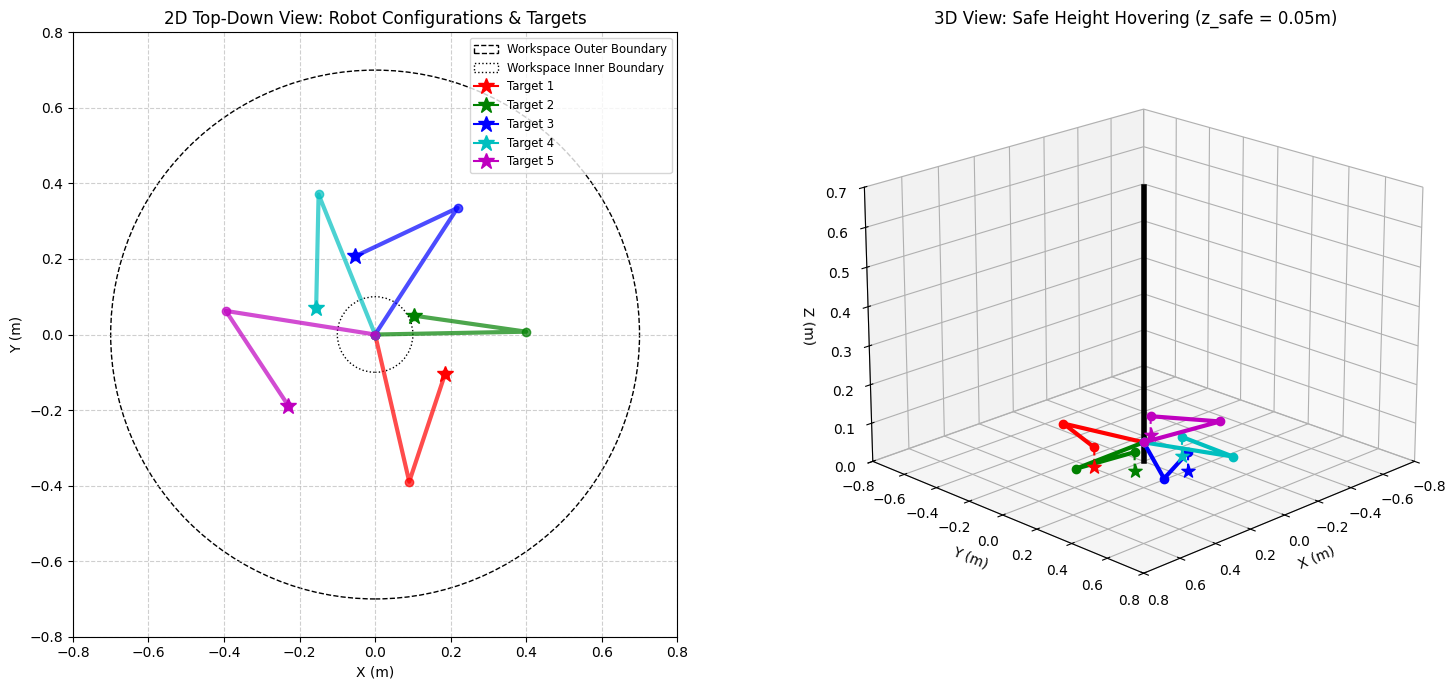

In [11]:
from mpl_toolkits.mplot3d import Axes3D

# --- 1. Define robot constants and parameters ---
L2 = 0.40  # meters
L3 = 0.30  # meters
D0 = 0.70  # meters
z_safe = 0.05  # meters

# Ground-truth disk coordinates
targets = [
    {"name": "Disk 1", "coord": [0.1850, -0.1050]},
    {"name": "Disk 2", "coord": [0.1030, 0.0500]},
    {"name": "Disk 3", "coord": [-0.0530, 0.2070]},
    {"name": "Disk 4", "coord": [-0.1560, 0.0710]},
    {"name": "Disk 5", "coord": [-0.2300, -0.1880]}
]

# Algebraic calculation of q1
q1_val = z_safe - D0

# --- 2. Kinematics and search functions ---
def forward_kinematics_xy(q2, q3):
    """Compute x and y position using forward kinematics"""
    x = L2 * np.cos(q2) + L3 * np.cos(q2 + q3)
    y = L2 * np.sin(q2) + L3 * np.sin(q2 + q3)
    return x, y

def search_ik_2d(xt, yt):
    """Two-stage brute-force search to find q2 and q3"""
    # Stage 1: Coarse search
    q2_coarse = np.linspace(-np.pi, np.pi, 200)
    q3_coarse = np.linspace(-np.pi, np.pi, 200)
    Q2_C, Q3_C = np.meshgrid(q2_coarse, q3_coarse)
    
    X_C, Y_C = forward_kinematics_xy(Q2_C, Q3_C)
    Error_C = np.sqrt((X_C - xt)**2 + (Y_C - yt)**2)
    
    # Find index of minimum error in coarse stage
    min_idx_c = np.unravel_index(np.argmin(Error_C), Error_C.shape)
    best_q2_c = Q2_C[min_idx_c]
    best_q3_c = Q3_C[min_idx_c]
    
    # Stage 2: Fine search
    search_radius = 0.1 # radians
    q2_fine = np.linspace(best_q2_c - search_radius, best_q2_c + search_radius, 300)
    q3_fine = np.linspace(best_q3_c - search_radius, best_q3_c + search_radius, 300)
    Q2_F, Q3_F = np.meshgrid(q2_fine, q3_fine)
    
    X_F, Y_F = forward_kinematics_xy(Q2_F, Q3_F)
    Error_F = np.sqrt((X_F - xt)**2 + (Y_F - yt)**2)
    
    # Find index of minimum error in fine stage
    min_idx_f = np.unravel_index(np.argmin(Error_F), Error_F.shape)
    best_q2_f = Q2_F[min_idx_f]
    best_q3_f = Q3_F[min_idx_f]
    min_error = Error_F[min_idx_f]
    
    return best_q2_f, best_q3_f, min_error

# --- 3. Execute Algorithm for All Targets ---
results = []
print(f"Calculated Prismatic Joint (q1): {q1_val:.3f} m\n")
print(f"{'Target':<10} | {'xt (m)':<8} | {'yt (m)':<8} | {'q2 (rad)':<10} | {'q3 (rad)':<10} | {'Error (mm)':<10} | {'Success (<5mm)':<15}")
print("-" * 85)

for target in targets:
    xt, yt = target["coord"]
    q2_opt, q3_opt, error_m = search_ik_2d(xt, yt)
    error_mm = error_m * 1000
    success = "YES" if error_mm < 5 else "NO"
    
    results.append({
        "name": target["name"],
        "xt": xt, "yt": yt,
        "q2": q2_opt, "q3": q3_opt,
        "error_mm": error_mm
    })
    
    print(f"{target['name']:<10} | {xt:>8.4f} | {yt:>8.4f} | {q2_opt:>10.4f} | {q3_opt:>10.4f} | {error_mm:>10.3f} | {success:^15}")

# --- 4. Visualization ---
fig = plt.figure(figsize=(16, 7))

# 4.1 2D Plot (Top-Down View)
ax1 = fig.add_subplot(121)
ax1.set_title("2D Top-Down View: Robot Configurations & Targets")
ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
ax1.set_aspect('equal')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plotting workspace boundaries
circle_outer = plt.Circle((0, 0), L2 + L3, color='k', fill=False, linestyle='--', label='Workspace Outer Boundary')
circle_inner = plt.Circle((0, 0), abs(L2 - L3), color='k', fill=False, linestyle=':', label='Workspace Inner Boundary')
ax1.add_patch(circle_outer)
ax1.add_patch(circle_inner)

colors = ['r', 'g', 'b', 'c', 'm']
for i, res in enumerate(results):
    c = colors[i]
    # Joint coordinates
    x0, y0 = 0, 0
    x1, y1 = L2 * np.cos(res["q2"]), L2 * np.sin(res["q2"])
    x2, y2 = res["xt"], res["yt"]
    
    # Plotting target
    ax1.plot(res["xt"], res["yt"], marker='*', color=c, markersize=12, label=f"Target {i+1}")
    # Plotting arms
    ax1.plot([x0, x1, x2], [y0, y1, y2], color=c, linewidth=3, marker='o', alpha=0.7)

ax1.set_xlim(-0.8, 0.8)
ax1.set_ylim(-0.8, 0.8)
ax1.legend(loc='upper right', fontsize='small')

# 4.2 3D Plot
ax2 = fig.add_subplot(122, projection='3d')
ax2.set_title(f"3D View: Safe Height Hovering (z_safe = {z_safe}m)")
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Y (m)")
ax2.set_zlabel("Z (m)")

# Plotting robot base
ax2.plot([0, 0], [0, 0], [0, D0], color='k', linewidth=4, label='Robot Base (D0)')

for i, res in enumerate(results):
    c = colors[i]
    x0, y0 = 0, 0
    x1, y1 = L2 * np.cos(res["q2"]), L2 * np.sin(res["q2"])
    x2, y2 = res["xt"], res["yt"]
    
    # Plotting robot arms at z_safe height
    ax2.plot([x0, x1, x2], [y0, y1, y2], [z_safe, z_safe, z_safe], color=c, linewidth=3, marker='o')
    # Plotting target disk on the table (Z=0)
    ax2.scatter(x2, y2, 0, color=c, marker='*', s=100)
    # Plotting vertical dashed line indicating safe distance
    ax2.plot([x2, x2], [y2, y2], [0, z_safe], color=c, linestyle='--')

ax2.set_xlim(-0.8, 0.8)
ax2.set_ylim(-0.8, 0.8)
ax2.set_zlim(0, D0)
ax2.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()


# Section C: PyBullet 

In [ ]:
import pybullet as p
import pybullet_data
import time
import numpy as np
import tempfile
import os

# ==========================================
# 0. Apply URDF Corrections & Re-generate
# ==========================================
L2 = 0.40
L3 = 0.30  # Corrected to match math (was 0.35 in task C.1 snippet)
D0 = 0.70
Q1_MIN = -0.70 # Corrected to allow reaching z_safe = 0.05
Q1_MAX = 0.50
z_safe = 0.05
q1_val = z_safe - D0  # -0.650

# Recreate the URDF string with corrected parameters
URDF_TEXT = f"""\
<?xml version="1.0"?>
<robot name="prr_robot">
  <link name="base_link">
    <visual><geometry><cylinder radius="0.18" length="0.20"/></geometry><origin xyz="0 0 0.10"/><material name="dark"><color rgba="0.25 0.25 0.27 1"/></material></visual>
    <inertial><mass value="10"/><inertia ixx="0.2" ixy="0" ixz="0" iyy="0.2" iyz="0" izz="0.2"/></inertial>
  </link>
  <link name="link1">
    <visual><geometry><box size="0.10 0.10 0.50"/></geometry><origin xyz="0 0 0.25"/><material name="blue"><color rgba="0.20 0.45 0.85 1"/></material></visual>
    <inertial><mass value="2.5"/><origin xyz="0 0 0.25"/><inertia ixx="0.06" ixy="0" ixz="0" iyy="0.06" iyz="0" izz="0.01"/></inertial>
  </link>
  <joint name="j1_prismatic" type="prismatic">
    <parent link="base_link"/><child link="link1"/><origin xyz="0 0 0.20"/><axis xyz="0 0 1"/><limit lower="{Q1_MIN}" upper="{Q1_MAX}" effort="200" velocity="1"/>
  </joint>
  <link name="link2">
    <visual><geometry><box size="{L2} 0.07 0.07"/></geometry><origin xyz="{L2/2} 0 0"/><material name="orange"><color rgba="0.95 0.55 0.10 1"/></material></visual>
    <inertial><mass value="1.0"/><origin xyz="{L2/2} 0 0"/><inertia ixx="0.005" ixy="0" ixz="0" iyy="0.030" iyz="0" izz="0.030"/></inertial>
  </link>
  <joint name="j2_revolute" type="continuous">
    <parent link="link1"/><child link="link2"/><origin xyz="0 0 0.50"/><axis xyz="0 0 1"/>
  </joint>
  <link name="link3">
    <visual><geometry><box size="{L3} 0.06 0.06"/></geometry><origin xyz="{L3/2} 0 0"/><material name="green"><color rgba="0.20 0.75 0.30 1"/></material></visual>
    <inertial><mass value="0.7"/><origin xyz="{L3/2} 0 0"/><inertia ixx="0.003" ixy="0" ixz="0" iyy="0.020" iyz="0" izz="0.020"/></inertial>
  </link>
  <joint name="j3_revolute" type="continuous">
    <parent link="link2"/><child link="link3"/><origin xyz="{L2} 0 0"/><axis xyz="0 0 1"/>
  </joint>
  <link name="ee">
    <visual><geometry><sphere radius="0.025"/></geometry><material name="yellow"><color rgba="1.0 0.85 0.10 1"/></material></visual>
    <inertial><mass value="0.05"/><inertia ixx="1e-5" ixy="0" ixz="0" iyy="1e-5" iyz="0" izz="1e-5"/></inertial>
  </link>
  <joint name="ee_fixed" type="fixed">
    <parent link="link3"/><child link="ee"/><origin xyz="{L3} 0 0"/>
  </joint>
</robot>
"""

# Save URDF
URDF_PATH = os.path.join(tempfile.gettempdir(), "prr_robot_corrected.urdf")
with open(URDF_PATH, "w") as f:
    f.write(URDF_TEXT)

# ==========================================
# 1. Setup PyBullet Environment (Task C.2)
# ==========================================
if p.isConnected():
    p.disconnect()

client_id = p.connect(p.GUI) 
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setGravity(0, 0, -9.81)

# Load Plane (Workbench surface at z=0)
plane_id = p.loadURDF("plane.urdf")

# Load Robot at origin
robot_id = p.loadURDF(URDF_PATH, basePosition=[0, 0, 0], useFixedBase=True)

# Map joint names to PyBullet indices
joint_indices = {}
for i in range(p.getNumJoints(robot_id)):
    info = p.getJointInfo(robot_id, i)
    name = info[1].decode('utf-8')
    joint_indices[name] = i

j1_idx = joint_indices['j1_prismatic']
j2_idx = joint_indices['j2_revolute']
j3_idx = joint_indices['j3_revolute']
ee_idx = joint_indices['ee_fixed']

# ==========================================
# 2. Spawn Target Disks on the Table
# ==========================================
targets = [
    {"name": "Disk 1", "xt": 0.1850, "yt": -0.1050, "q2": -1.3429, "q3": 2.5925, "rgba": [1, 0, 0, 1]},  # Red
    {"name": "Disk 2", "xt": 0.1030, "yt": 0.0500,  "q2": 0.0188,  "q3": 2.9807, "rgba": [1, 0, 0, 1]},  # Red
    {"name": "Disk 3", "xt": -0.0530,"yt": 0.2070,  "q2": 0.9936,  "q3": 2.5898, "rgba": [0, 1, 0, 1]},  # Green
    {"name": "Disk 4", "xt": -0.1560,"yt": 0.0710,  "q2": 1.9542,  "q3": 2.7368, "rgba": [0, 1, 0, 1]},  # Green
    {"name": "Disk 5", "xt": -0.2300,"yt": -0.1880, "q2": 2.9847,  "q3": 2.3103, "rgba": [0, 0, 1, 1]}   # Blue
]

for tgt in targets:
    visual_shape = p.createVisualShape(shapeType=p.GEOM_CYLINDER, radius=0.022, length=0.01, rgbaColor=tgt["rgba"])
    p.createMultiBody(baseMass=0, baseVisualShapeIndex=visual_shape, basePosition=[tgt["xt"], tgt["yt"], 0.005])

# ==========================================
# 3. Kinematics Validation (Task C.3)
# ==========================================
def fk_math(q1, q2, q3):
    x = L2 * np.cos(q2) + L3 * np.cos(q2 + q3)
    y = L2 * np.sin(q2) + L3 * np.sin(q2 + q3)
    z = D0 + q1
    return np.array([x, y, z])

print("="*95)
print(f"{'Target':<10} | {'PyBullet EE (x, y, z) [m]':<35} | {'Math FK (x, y, z) [m]':<30} | {'Error [mm]':<10}")
print("="*95)

time.sleep(1)

for tgt in targets:
    p.resetJointState(robot_id, j1_idx, q1_val)
    p.resetJointState(robot_id, j2_idx, tgt["q2"])
    p.resetJointState(robot_id, j3_idx, tgt["q3"])
    
    p.stepSimulation()
    time.sleep(0.5) 
    
    ee_state = p.getLinkState(robot_id, ee_idx)
    ee_pos_pb = np.array(ee_state[0])
    
    ee_pos_math = fk_math(q1_val, tgt["q2"], tgt["q3"])
    
    error_m = np.linalg.norm(ee_pos_pb - ee_pos_math)
    error_mm = error_m * 1000
    
    pb_str = f"({ee_pos_pb[0]:+.4f}, {ee_pos_pb[1]:+.4f}, {ee_pos_pb[2]:+.4f})"
    math_str = f"({ee_pos_math[0]:+.4f}, {ee_pos_math[1]:+.4f}, {ee_pos_math[2]:+.4f})"
    print(f"{tgt['name']:<10} | {pb_str:<35} | {math_str:<30} | {error_mm:.4f}")

print("="*95)


Target     | PyBullet EE (x, y, z) [m]           | Math FK (x, y, z) [m]          | Error [mm]
Disk 1     | (+0.1851, -0.1050, +0.0500)         | (+0.1851, -0.1050, +0.0500)    | 0.0000
Disk 2     | (+0.1030, +0.0500, +0.0500)         | (+0.1030, +0.0500, +0.0500)    | 0.0000
Disk 3     | (-0.0529, +0.2069, +0.0500)         | (-0.0529, +0.2069, +0.0500)    | 0.0000
Disk 4     | (-0.1560, +0.0710, +0.0500)         | (-0.1560, +0.0710, +0.0500)    | 0.0000
Disk 5     | (-0.2300, -0.1880, +0.0500)         | (-0.2300, -0.1880, +0.0500)    | 0.0000


Starting animation rendering. This might take a few seconds...
Animation saved successfully as: robot_inspection_process.gif
Physics server disconnected safely.


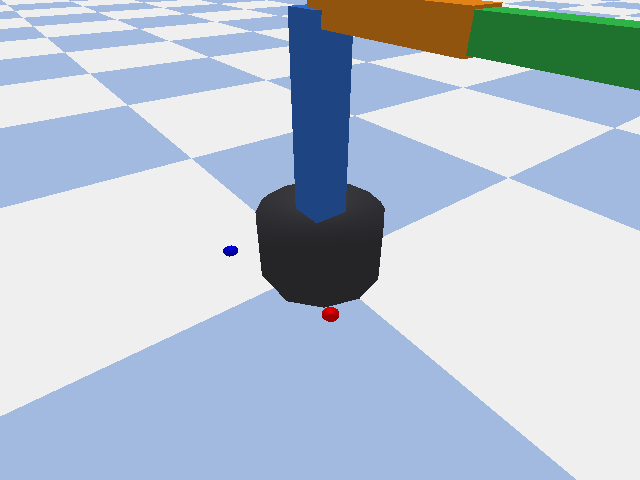

In [ ]:
import pybullet as p
import numpy as np
import imageio
from IPython.display import Image, display

if not p.isConnected():
    raise RuntimeError("Physics server is not connected! لطفاً ابتدا سلول قبلی را اجرا کنید.")

# ==========================================
# 1. Define Waypoints (Trajectory Setup)
# ==========================================
q_home = np.array([0.0, 0.0, 0.0])

z_safe_q1 = -0.650
q_targets = [
    np.array([z_safe_q1, -1.3429, 2.5925]), # Target 1 (Red)
    np.array([z_safe_q1,  0.0188, 2.9807]), # Target 2 (Red)
    np.array([z_safe_q1,  0.9936, 2.5898]), # Target 3 (Green)
    np.array([z_safe_q1,  1.9542, 2.7368]), # Target 4 (Green)
    np.array([z_safe_q1,  2.9847, 2.3103])  # Target 5 (Blue)
]

waypoints = [q_home] + q_targets + [q_home]

# ==========================================
# 2. Virtual Camera Setup
# ==========================================
img_width, img_height = 640, 480

view_matrix = p.computeViewMatrix(
    cameraEyePosition=[0.8, -0.6, 0.8], 
    cameraTargetPosition=[0, 0, 0.1],   
    cameraUpVector=[0, 0, 1]            
)

projection_matrix = p.computeProjectionMatrixFOV(
    fov=60.0, 
    aspect=float(img_width) / img_height, 
    nearVal=0.1, 
    farVal=100.0
)

# ==========================================
# 3. Execution & Rendering Loop
# ==========================================
frames = []
frames_per_segment = 16

print("Starting animation rendering. This might take a few seconds...")

for i in range(len(waypoints) - 1):
    q_start = waypoints[i]
    q_end = waypoints[i + 1]
    
    for step in range(frames_per_segment):
        alpha = step / float(frames_per_segment)
        q_current = (1.0 - alpha) * q_start + alpha * q_end
        
        p.resetJointState(robot_id, j1_idx, q_current[0])
        p.resetJointState(robot_id, j2_idx, q_current[1])
        p.resetJointState(robot_id, j3_idx, q_current[2])
        
        p.stepSimulation()
        
        img_arr = p.getCameraImage(
            img_width, img_height, 
            view_matrix, projection_matrix, 
            renderer=p.ER_TINY_RENDERER 
        )
        
        rgba = np.reshape(img_arr[2], (img_height, img_width, 4))
        rgb = rgba[:, :, :3].astype(np.uint8)
        frames.append(rgb)

# ==========================================
# 4. Save, Clean up, and Display
# ==========================================
gif_path = "robot_inspection_process.gif"

imageio.mimsave(gif_path, frames, duration=0.05)
print(f"Animation saved successfully as: {gif_path}")

p.disconnect()
print("Physics server disconnected safely.")

display(Image(filename=gif_path))

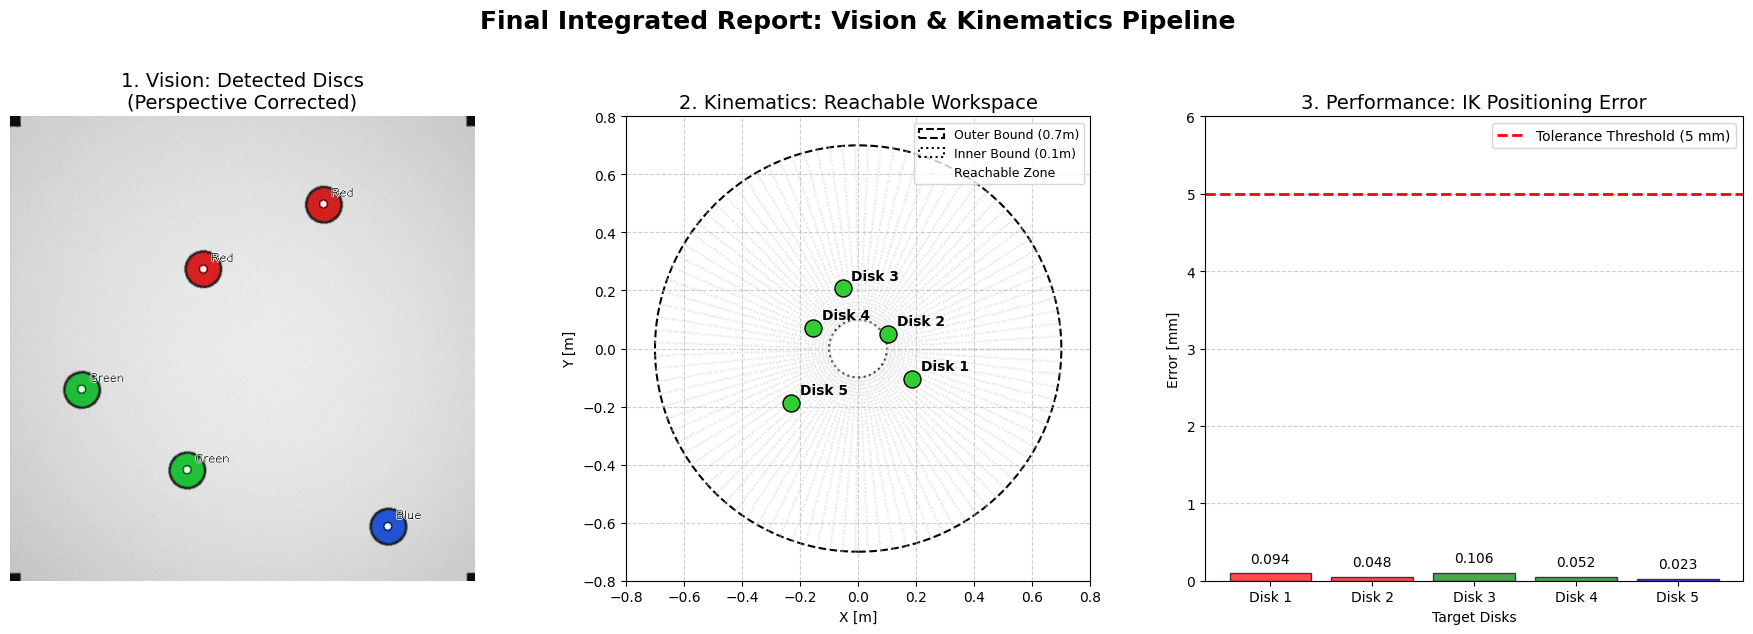

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle


# ==========================================
# 1. Prepare Data from previous tasks
# ==========================================
L2 = 0.40
L3 = 0.30
r_inner = abs(L2 - L3)  # 0.10 m
r_outer = L2 + L3       # 0.70 m

targets_data = [
    {"name": "Disk 1", "xt": 0.1850, "yt": -0.1050, "error": 0.094, "color": "red"},
    {"name": "Disk 2", "xt": 0.1030, "yt": 0.0500,  "error": 0.048, "color": "red"},
    {"name": "Disk 3", "xt": -0.0530,"yt": 0.2070,  "error": 0.106, "color": "green"},
    {"name": "Disk 4", "xt": -0.1560,"yt": 0.0710,  "error": 0.052, "color": "green"},
    {"name": "Disk 5", "xt": -0.2300,"yt": -0.1880, "error": 0.023, "color": "blue"}
]

names = [t["name"] for t in targets_data]
x_coords = [t["xt"] for t in targets_data]
y_coords = [t["yt"] for t in targets_data]
errors = [t["error"] for t in targets_data]
colors = [t["color"] for t in targets_data]

# ==========================================
# 2. Create the Integrated Figure
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Final Integrated Report: Vision & Kinematics Pipeline', fontsize=18, fontweight='bold', y=1.05)

# ---------------------------------------------------------
# Subplot 1: Vision Output (Segmented Image)
# ---------------------------------------------------------
try:
    axs[0].imshow(visualization_rgb)
    axs[0].set_title("1. Vision: Detected Discs\n(Perspective Corrected)", fontsize=14)
    axs[0].axis('off')
except NameError:
    axs[0].text(0.5, 0.5, 'Image Data Not Found\n(Run Task A.4 first)', 
                horizontalalignment='center', verticalalignment='center', fontsize=12)
    axs[0].axis('off')

# ---------------------------------------------------------
# Subplot 2: Reachable Workspace Schematic
# ---------------------------------------------------------
axs[1].set_title("2. Kinematics: Reachable Workspace", fontsize=14)
axs[1].set_xlabel("X [m]")
axs[1].set_ylabel("Y [m]")
axs[1].set_aspect('equal')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].set_xlim(-0.8, 0.8)
axs[1].set_ylim(-0.8, 0.8)

circle_outer = Circle((0, 0), r_outer, color='black', fill=False, linestyle='--', linewidth=1.5, label='Outer Bound (0.7m)')
circle_inner = Circle((0, 0), r_inner, color='black', fill=False, linestyle=':', linewidth=1.5, label='Inner Bound (0.1m)')
axs[1].add_patch(circle_outer)
axs[1].add_patch(circle_inner)

theta = np.linspace(0, 2*np.pi, 100)
r = np.linspace(r_inner, r_outer, 50)
T, R = np.meshgrid(theta, r)
X_area = R * np.cos(T)
Y_area = R * np.sin(T)
axs[1].scatter(X_area, Y_area, color='lightgray', s=1, alpha=0.3, label='Reachable Zone')

for i, t in enumerate(targets_data):
    dist = np.sqrt(t["xt"]**2 + t["yt"]**2)
    marker_color = 'limegreen' if r_inner <= dist <= r_outer else 'red'
    
    axs[1].scatter(t["xt"], t["yt"], color=marker_color, s=150, edgecolors='black', zorder=5)
    axs[1].text(t["xt"] + 0.03, t["yt"] + 0.03, t["name"], fontsize=10, weight='bold')

axs[1].legend(loc='upper right', fontsize=9)

# ---------------------------------------------------------
# Subplot 3: Error Bar Chart
# ---------------------------------------------------------
axs[2].set_title("3. Performance: IK Positioning Error", fontsize=14)
axs[2].set_xlabel("Target Disks")
axs[2].set_ylabel("Error [mm]")

bars = axs[2].bar(names, errors, color=colors, edgecolor='black', alpha=0.7)

axs[2].axhline(y=5.0, color='red', linestyle='--', linewidth=2, label='Tolerance Threshold (5 mm)')

for bar, err in zip(bars, errors):
    yval = bar.get_height()
    axs[2].text(bar.get_x() + bar.get_width()/2.0, yval + 0.1, f'{err:.3f}', ha='center', va='bottom', fontsize=10)

axs[2].set_ylim(0, 6) 
axs[2].grid(axis='y', linestyle='--', alpha=0.6)
axs[2].legend(loc='upper right')

# ==========================================
# 3. Final Layout Adjustment
# ==========================================
plt.tight_layout()
plt.show()